In [25]:
from get_noise_sigma import load_dataset

dataset_name = ['TIMIT-sentence_type-16k', 'TIMIT-gender-16k', 'TIMIT-dialect-16k']
dataset_name = ['TIMIT-sentence_type-16k']
for dataset in dataset_name:
    data = load_dataset(dataset)

    import numpy as np 
    key1 = 'TRAIN'
    audio = {key1: {}}
    for key2 in data[key1].keys():
        audio[key1][key2] = {}
        for key3 in data[key1][key2].keys():
            l = [(10 ** (i / 10)).sum(axis=-1).mean() for i in data[key1][key2][key3]]
            audio[key1][key2][key3] = l
            if "FJSP0" in key3:
                d = [i for i in data[key1][key2][key3]]
                size_l = [[i.shape for i in data[key1][key2][key3]]]
                # print(l, np.mean(l), np.std(l))
                
                if len(size_l)>0:
                    print(l)
                    print(size_l)
    # audio

    key1 = 'TRAIN'
    s = []
    for key2 in audio[key1].keys():
        for key3 in audio[key1][key2].keys():
            s.append(np.mean(audio[key1][key2][key3]))
    np.mean(s)

    from get_noise_sigma import get_gaussian_sigma
    print(f'=========={dataset}==========')
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -20))
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -15))
    print("H, 0dB:", get_gaussian_sigma(np.mean(s), 0))
    print("M, 15dB:", get_gaussian_sigma(np.mean(s), 15)) 
    print("L, 25dB:", get_gaussian_sigma(np.mean(s), 25))

[0.5865394, 0.67150676, 0.47556317, 0.4730428, 0.56988645, 0.5005794, 0.3759934, 0.15124355, 0.61658335, 0.53292525]
[[(1, 439, 64), (1, 289, 64), (1, 124, 64), (1, 383, 64), (1, 289, 64), (1, 347, 64), (1, 269, 64), (1, 251, 64), (1, 358, 64), (1, 274, 64)]]
==========TIMIT-sentence_type-16k==========
H, -15dB: 5.2243327129946735
H, -15dB: 2.9378581810607165
H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162


In [31]:
for i in range(-50, 25, 5):
    print(i)

-50
-45
-40
-35
-30
-25
-20
-15
-10
-5
0
5
10
15
20


In [21]:
import numpy as np 

d = np.load('autrainer-configurations/data/TIMIT-sentence_type/log_mel_16k/TRAIN/DR1/FJSP0/SI1763.npy')
d.shape

(1, 124, 64)

In [7]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [12]:
(10 ** (data[key1][key2][key3][0] / 10)).max()

0.04616595

In [15]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [2]:
import autrainer 
autrainer.__file__

KeyboardInterrupt: 

In [7]:
np.mean(s)

0.27293652

In [6]:
snr_db = 0
(10 ** (snr_db/10))

1.0

In [33]:
key1 = 'TRAIN'
db = []
for key2 in audio[key1].keys():
    for key3 in audio[key1][key2].keys():
        db.append(10 * np.log10(np.array(audio[key1][key2][key3]) / 0.2729))
np.concatenate(db).mean()

-1.9086657

In [10]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', "GaussianNoise(H)", "GaussianNoise(L)"]
for train_post in post:
    for test_post in post:
        path = f'./results/noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_{train_post}_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(train_post, test_post, data['f1']['all'])

GaussianNoise(neg20) GaussianNoise(neg20) 0.7138454800834301
GaussianNoise(neg20) GaussianNoise(H) 0.4678583546919213
GaussianNoise(neg20) GaussianNoise(L) 0.4726268895058703
GaussianNoise(H) GaussianNoise(neg20) 0.4092137087915915
GaussianNoise(H) GaussianNoise(H) 0.7427364436748221
GaussianNoise(H) GaussianNoise(L) 0.7408558179385314
GaussianNoise(L) GaussianNoise(neg20) 0.12900346626573586
GaussianNoise(L) GaussianNoise(H) 0.73035910687168
GaussianNoise(L) GaussianNoise(L) 0.7363988916054165


In [11]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/noise/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data['f1']['all'])  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) 0.29222265004359355
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) 0.7161862794284763
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) 0.7402195443881782


In [9]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/clean/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_None_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data)  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}


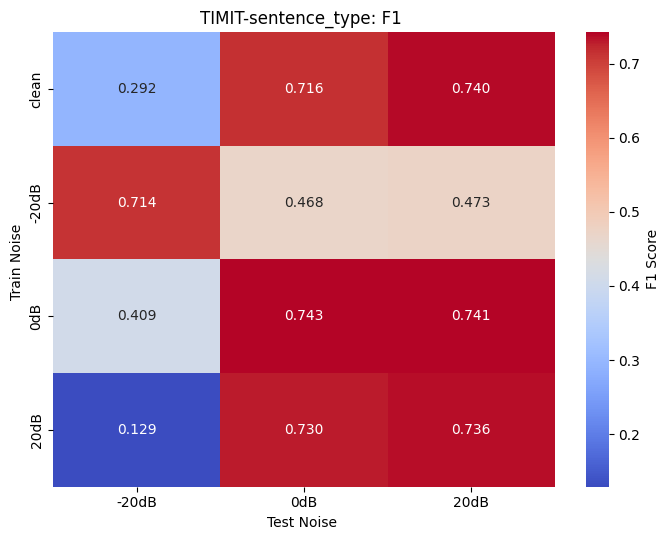

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 定义数据
train_conditions = ["clean", "-20dB", "0dB", "20dB"]
test_conditions = ["-20dB", "0dB", "20dB"]


# 添加干净训练的测试结果
values = np.array([
    [0.29222265004359355, 0.7161862794284763, 0.7402195443881782],  # Clean train
    [0.7138454800834301, 0.4678583546919213, 0.4726268895058703],    # Gaussian(neg20) train
    [0.4092137087915915, 0.7427364436748221, 0.7408558179385314],    # Gaussian(H) train
    [0.12900346626573586, 0.73035910687168, 0.7363988916054165]      # Gaussian(L) train
])

# 画heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(values, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'F1 Score'})

plt.title("TIMIT-sentence_type: F1 ")
plt.xlabel("Test Noise ")
plt.ylabel("Train Noise ")
plt.tight_layout()
plt.show()


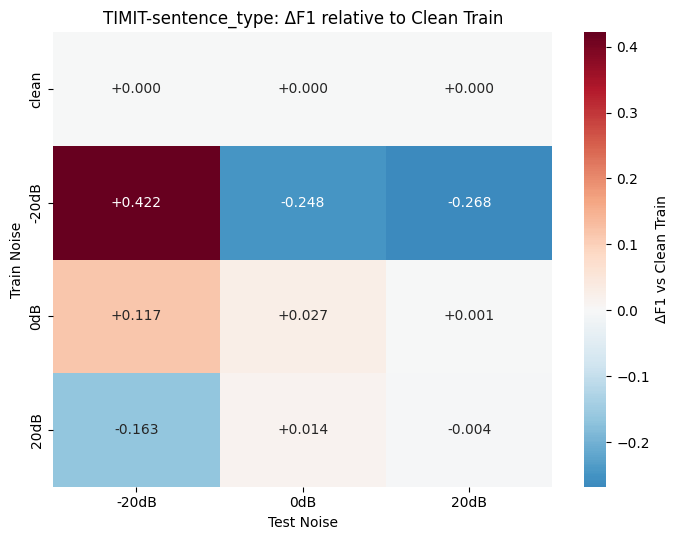


横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。



In [22]:
# 1️⃣ 计算相对clean的差值矩阵
diff_values = values - values[0]  # 每列相对clean训练的差值

# 画差值heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(diff_values, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'ΔF1 vs Clean Train'})

plt.title("TIMIT-sentence_type: ΔF1 relative to Clean Train")
plt.xlabel("Test Noise")
plt.ylabel("Train Noise")
plt.tight_layout()
plt.show()

# 2️⃣ 分析总结文本
analysis = """
横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。
"""
print(analysis)


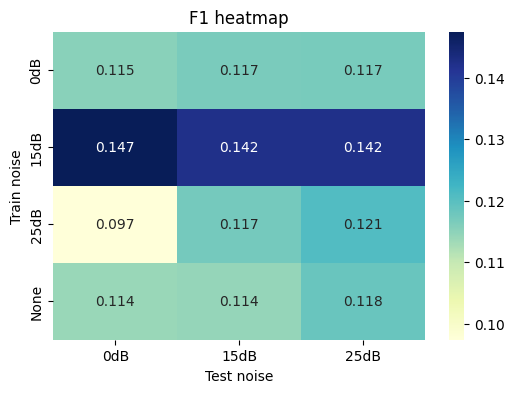

In [11]:
import seaborn as sns
pivot = df.pivot(index="train", columns="test", values="F1")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("F1 heatmap")
plt.ylabel("Train noise")
plt.xlabel("Test noise")
plt.show()


In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("agkphysics/AudioSet", "balanced")

/jumbo/graphmind/yinghao/miniconda3/envs/ASL1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import torchaudio

In [3]:
import torchaudio
import torch
import datasets
import io
import numpy as np

# Mel 变换器
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    win_length=400,
    hop_length=160,
    n_mels=64,
)

amp_to_db = torchaudio.transforms.AmplitudeToDB()

# 统一 mel 时间长度
MAX_FRAMES = 1024   # 可调整

def pad_or_trim(feature, max_len=MAX_FRAMES):
    """
    输入: feature shape (64, T)
    输出: 固定 (64, max_len)
    """
    T = feature.shape[1]

    if T == max_len:
        return feature

    if T > max_len:
        return feature[:, :max_len]

    # pad
    pad_width = max_len - T
    pad = np.zeros((feature.shape[0], pad_width), dtype=feature.dtype)
    return np.concatenate([feature, pad], axis=1)


def preprocess(batch):
    audio = batch["audio"]

    # audio 始终包含 bytes
    waveform, sr = torchaudio.load(io.BytesIO(audio["bytes"]))   # (C, T)

    # 转 mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # resample
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # mel
    mel = mel_transform(waveform)    # (1, 64, T)
    logmel = amp_to_db(mel)[0].numpy()  # (64, T)

    # 固定长度
    logmel = pad_or_trim(logmel, MAX_FRAMES)

    # 返回
    batch["log_mel"] = logmel  # shape (64, MAX_FRAMES)
    return batch


# 强制 audio 用 bytes
ds = ds.cast_column("audio", datasets.Audio(decode=False))

# 运行
ds_logmel = ds.map(preprocess)


In [4]:
for split in ['train', 'test']:
    for i in range(len(ds_logmel[split])):
        ds_logmel[split][i]['log_mel'] = torch.tensor(ds_logmel[split][i]['log_mel'])

In [ ]:
from collections import defaultdict

inverted_index = defaultdict(list)

train_ds = ds_logmel['train']

for i in range(len(train_ds)):
    labels = train_ds[i]['human_labels']   # 可能是 list[str]
    for lb in labels:
        inverted_index[lb].append(i)


In [10]:
for i in inverted_index['Thunder']:
    # if 'Wind' in train_ds[i]['human_labels']:
    #     print(i)
    print(train_ds[i]['human_labels'])

['Rain', 'Raindrop', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rustle', 'Thunderstorm', 'Thunder']
['Rain', 'Raindrop', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunder']
['Rain', 'Raindrop', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rustle', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Rustle', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder']
['Rain', 'Thunderstorm', 'Thunder', 'Rain on surface']
['Rai

In [6]:
from collections import defaultdict
import itertools

train_ds = ds_logmel['train']

# 1. 收集所有标签
all_labels = set()
for i in range(len(train_ds)):
    for lb in train_ds[i]["human_labels"]:
        all_labels.add(lb)
all_labels = sorted(all_labels)

# 2. 初始化矩阵
overlap = {a: defaultdict(int) for a in all_labels}

# 3. 统计重叠
for i in range(len(train_ds)):
    labels = train_ds[i]["human_labels"]
    # 每条样本里的标签两两组合
    for a, b in itertools.combinations(sorted(labels), 2):
        overlap[a][b] += 1
        overlap[b][a] += 1  # 对称矩阵


In [8]:
torch.save((overlap, ds_logmel), 'AudioSet.pt')

In [1]:
import torch 

overlap, ds_logmel = torch.load('AudioSet.pt')


/tmp/ipykernel_371984/3460888528.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  overlap, ds_logmel = torch.load('AudioSet.pt')
/jumbo/graphmind/yinghao/miniconda3/envs/

In [ ]:
my_set = set([])
for i in range(len(ds_logmel['train'])):
    my_set = ds_logmel['train'][i]['human_labels']
    

['Speech', 'Gush']

In [6]:
'pink noise' in {name.lower(): idx for idx, name in enumerate(overlap.keys())}.keys()

True

In [ ]:
# Audio Set 本体分析
import pandas as pd
import numpy as np
from collections.abc import Iterable

name_to_id_dict = {name.lower(): idx for idx, name in enumerate(overlap.keys())}
id_to_name_dict = {idx : name.lower() for idx, name in enumerate(overlap.keys())}

def name_id(name):
    def sub_name_id(n):
        n = n.lower()
        if n not in name_to_id_dict.keys():
            print(n)
            assert False
        return name_to_id_dict[n]
    
    if isinstance(name, Iterable):
        return [sub_name_id(n) for n in name]
    else:
        return sub_name_id[name]
        
def id_name(ids):
    def sub_id_name(i):
        if i not in id_to_name_dict.keys():
            print(i)
            assert False
        return id_to_name_dict[i]
    
    if isinstance(i, Iterable):
        return [sub_id_name(n) for n in ids]
    else:
        return sub_id_name[ids]

df = pd.DataFrame(0, index=overlap.keys(), columns=overlap.keys())
for row, inner in overlap.items():
    for col, val in inner.items():
        df.loc[row, col] = val
df = df.fillna(0).astype(int)
data_adj = df.to_numpy()

# n_hop neighbors
def get_n_hop_neighbors(adj, node_id, n_hop=1):
    adj = adj + np.eye(len(adj))
    adj = (adj > 0)
    
    N = adj.shape[0]
    
    reach = adj.copy().astype(bool)
    current = adj.copy().astype(bool) 

    for hop in range(2, n_hop + 1):
        current = (current @ adj) > 0
        reach = reach | current
    
    if isinstance(node_id, Iterable):
        neighbors = []
        for id in node_id:
            # print(np.where(reach[id]))
            neighbors.append(np.where(reach[id])[0])
        return neighbors
    else:
        return np.where(reach[node_id])[0]
    
# Natural Sounds: Wind, Thunderstorm, Water, Fire
names = ['Wind', 'Thunderstorm', 'Water', 'Fire']
name_id(names)
import numpy as np
import pandas as pd
from collections.abc import Iterable

# ============ 辅助函数（你的写法稍微修复） ============
name_to_id_dict = {name.lower(): idx for idx, name in enumerate(overlap.keys())}
id_to_name_dict = {idx: name for idx, name in enumerate(overlap.keys())}

def name_id(name):
    if isinstance(name, str):
        return name_to_id_dict[name.lower()]
    return [name_to_id_dict[n.lower()] for n in name]

def id_name(ids):
    if isinstance(ids, int):
        return id_to_name_dict[ids]
    return [id_to_name_dict[i] for i in ids]


# ================== 构建 DataFrame ==================
df = pd.DataFrame(0, index=overlap.keys(), columns=overlap.keys())
for row, inner in overlap.items():
    for col, val in inner.items():
        df.loc[row, col] = val

df = df.fillna(0).astype(int)


# ============ 任务 1：求 Wind / Thunderstorm / Water / Fire 的共现比例 ============
def top_related(tag, df, top_k=10):
    """返回某个标签共现比例最高的标签（除自身外）。"""
    row = df.loc[tag]
    col_total = df.sum(axis=0)  # N(B)

    scores = (row / (col_total + 1e-9)).sort_values(ascending=False)
    scores = scores.drop(tag)  # 去掉自身
    return scores.head(top_k)


targets = ['Wind', 'Thunderstorm', 'Water', 'Fire']

print("===== Task 1: Top related labels =====")
top_results = {}
for t in targets:
    res = top_related(t, df)
    top_results[t] = res
    print(f"\n### {t} 最相关标签 Top {len(res)}:")
    print(res)


# ============ 任务 2：将这些标签合成 4 个类，并统计类之间的共现频次 ============
def build_class(tag, top_res, include_self=True):
    """class = tag 本身 + top-k 最相关标签列表"""
    labels = list(top_res[tag].index)
    if include_self:
        labels = [tag] + labels
    return labels


classes = {t: build_class(t, top_results) for t in targets}

print("\n===== 四个类的标签集合 =====")
for k, v in classes.items():
    print(f"{k}: {v}")


# ======== 计算类之间共现（两类所有标签两两做 df lookup 的总和） ========
def class_cooccurrence(classA, classB, df):
    score = 0
    for a in classA:
        for b in classB:
            score += df.loc[a, b]
    return score

print("\n===== Task 2: 类与类之间的共现频次 =====")
class_names = targets
class_matrix = pd.DataFrame(0, index=class_names, columns=class_names)

for a in class_names:
    for b in class_names:
        class_matrix.loc[a, b] = class_cooccurrence(classes[a], classes[b], df)

print(class_matrix)


neighbors = get_n_hop_neighbors(data_adj, name_id(names))

In [83]:
import numpy as np
import pandas as pd
from collections.abc import Iterable

# ============ 辅助函数（你的写法稍微修复） ============
name_to_id_dict = {name.lower(): idx for idx, name in enumerate(overlap.keys())}
id_to_name_dict = {idx: name for idx, name in enumerate(overlap.keys())}

def name_id(name):
    if isinstance(name, str):
        return name_to_id_dict[name.lower()]
    return [name_to_id_dict[n.lower()] for n in name]

def id_name(ids):
    if isinstance(ids, int):
        return id_to_name_dict[ids]
    return [id_to_name_dict[i] for i in ids]


# ================== 构建 DataFrame ==================
df = pd.DataFrame(0, index=overlap.keys(), columns=overlap.keys())
for row, inner in overlap.items():
    for col, val in inner.items():
        df.loc[row, col] = val

df = df.fillna(0).astype(int)


# ============ 任务 1：求 Wind / Thunderstorm / Water / Fire 的共现比例 ============
def top_related(tag, df, top_k=10):
    row = df.loc[tag]             # N(A,B)
    row_total = row.sum() + 1e-9  # N(A)

    scores = (row / row_total).sort_values(ascending=False)
    scores = scores.drop(tag)
    return scores.head(top_k)


targets = ['Wind', 'Thunderstorm', 'Water', 'Fire']

print("===== Task 1: Top related labels =====")
top_results = {}
for t in targets:
    res = top_related(t, df)
    top_results[t] = res
    print(f"\n### {t} 最相关标签 Top {len(res)}:")
    print(res)


# ============ 任务 2：将这些标签合成 4 个类，并统计类之间的共现频次 ============
def build_class(tag, top_res, include_self=True):
    """class = tag 本身 + top-k 最相关标签列表"""
    labels = list(top_res[tag].index)
    if include_self:
        labels = [tag] + labels
    return labels


classes = {t: build_class(t, top_results) for t in targets}

print("\n===== 四个类的标签集合 =====")
for k, v in classes.items():
    print(f"{k}: {v}")


# ======== 计算类之间共现（两类所有标签两两做 df lookup 的总和） ========
def class_cooccurrence(classA, classB, df):
    score = 0
    for a in classA:
        for b in classB:
            score += df.loc[a, b]
    return score

print("\n===== Task 2: 类与类之间的共现频次 =====")
class_names = targets
class_matrix = pd.DataFrame(0, index=class_names, columns=class_names)

for a in class_names:
    for b in class_names:
        class_matrix.loc[a, b] = class_cooccurrence(classes[a], classes[b], df)

print(class_matrix)


===== Task 1: Top related labels =====

### Wind 最相关标签 Top 10:
Wind noise (microphone)    0.262397
Boat, Water vehicle        0.208678
Sailboat, sailing ship     0.099174
Waves, surf                0.090909
Ocean                      0.088843
Ship                       0.070248
Fire                       0.057851
Motorboat, speedboat       0.028926
Rowboat, canoe, kayak      0.020661
Wind chime                 0.008264
Name: Wind, dtype: float64

### Thunderstorm 最相关标签 Top 10:
Thunder                    0.352113
Rain                       0.323944
Rain on surface            0.147887
Raindrop                   0.105634
Rustle                     0.028169
Cupboard open or close     0.007042
Field recording            0.007042
Ocean                      0.007042
Wind noise (microphone)    0.007042
Speech                     0.007042
Name: Thunderstorm, dtype: float64

### Water 最相关标签 Top 10:
Water tap, faucet               0.179775
Sink (filling or washing)       0.134831
Pump (liquid)   

In [50]:
[i for i in df.columns if i.startswith('T')]

['Tabla',
 'Tambourine',
 'Tap',
 'Tapping (guitar technique)',
 'Tearing',
 'Techno',
 'Telephone',
 'Telephone bell ringing',
 'Telephone dialing, DTMF',
 'Television',
 'Tender music',
 'Theme music',
 'Theremin',
 'Throat clearing',
 'Throbbing',
 'Thump, thud',
 'Thunder',
 'Thunderstorm',
 'Thunk',
 'Tick',
 'Tick-tock',
 'Timpani',
 'Tire squeal',
 'Toilet flush',
 'Tools',
 'Toot',
 'Toothbrush',
 'Traditional music',
 'Traffic noise, roadway noise',
 'Train',
 'Train horn',
 'Train wheels squealing',
 'Train whistle',
 'Trance music',
 'Trickle, dribble',
 'Trombone',
 'Truck',
 'Trumpet',
 'Tubular bells',
 'Tuning fork',
 'Turkey',
 'Typewriter',
 'Typing']

TypeError: unhashable type: 'list'

In [30]:
type(data_adj) is np.ndarray

True

In [15]:
import matplotlib.pyplot as plt 
# plt.bar(df.columns, df.sum())
"Fire" in df.columns

True

In [13]:
import datasets
ds = ds.cast_column("audio", datasets.Audio(decode=False))

In [14]:
for i in range(len(ds['train'])):
    if 'bytes' not in ds['train'][i]['audio']:
        print(i)

In [15]:
'bytes' in ds['train'][0]['audio']

True

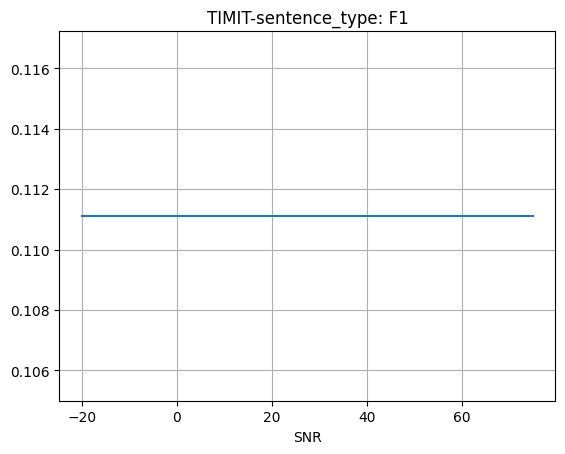

In [2]:
# Baseline: train on clean, test on noise
import yaml
import os
import matplotlib.pyplot as plt 
import numpy as np
data_dict = {}
for seed in [0,1,2]:
    for snr in range(-20, 80, 5):
        path = (
            f"results/test/training/"
            f"TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_"
            f"test({snr})_{seed}/_test/test_holistic.yaml"
        )

        with open(path, "r") as f:
            data = yaml.safe_load(f)   # ← 正确方式
            # print(snr, data['f1']['all'])
            if snr in data_dict:
                data_dict[snr].append(data['f1']['all'])
            else:
                data_dict[snr] = [data['f1']['all']]

x = list(data_dict.keys())
mean_list = np.array([np.mean(data_dict[s]) for s in x])
std_list = np.array([np.std(data_dict[s]) for s in x])
plt.plot(x, mean_list)
plt.title("TIMIT-sentence_type: F1")
plt.grid()
plt.xlabel("SNR")
plt.fill_between(x, mean_list-std_list, mean_list+std_list, alpha=0.5)

In [ ]:
# Baseline: train on clean, test on noise
import yaml
import os
import matplotlib.pyplot as plt 
import numpy as np
data_dict = {}
for seed in [0, 1, 2]:
    for snr in range(-50, 25, 5):
        path = (
            f"results/test/training/"
            f"TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_"
            f"test({snr})_{seed}/_test/test_holistic.yaml"
        )

        with open(path, "r") as f:
            data = yaml.safe_load(f)   # ← 正确方式
            # print(snr, data['f1']['all'])
            if snr in data_dict:
                data_dict[snr].append(data['f1']['all'])
            else:
                data_dict[snr] = [data['f1']['all']]

x = list(data_dict.keys())
mean_list = np.array([np.mean(data_dict[s]) for s in x])
std_list = np.array([np.std(data_dict[s]) for s in x])
plt.plot(x, mean_list)
plt.title("TIMIT-sentence_type: F1")
plt.grid()
plt.xlabel("SNR")
plt.fill_between(x, mean_list-std_list, mean_list+std_list, alpha=0.5)

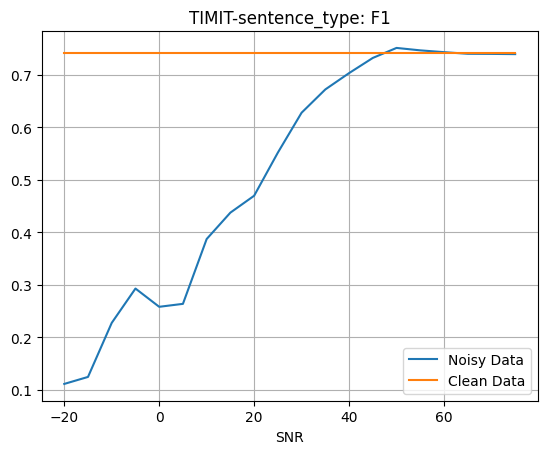

In [50]:
# Baseline: train on clean, test on noise
import yaml
import os
import matplotlib.pyplot as plt 
import numpy as np
data_dict = {}
for seed in [0]:
    for i,snr in enumerate(range(-20, 80, 5)):
        path = (
            f"results/test/training/"
            f"TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_"
            f"-20-75_{seed}/_test{i}/test_holistic.yaml"
        )

        with open(path, "r") as f:
            data = yaml.safe_load(f)   # ← 正确方式
            # print(snr, data['f1']['all'])
            if snr in data_dict:
                data_dict[snr].append(data['f1']['all'])
            else:
                data_dict[snr] = [data['f1']['all']]

x = list(data_dict.keys())
mean_list = np.array([np.mean(data_dict[s]) for s in x])
std_list = np.array([np.std(data_dict[s]) for s in x])
plt.plot(x, mean_list, label='Noisy Data')
plt.plot(x, np.ones(len(x))*0.7403149557990653, label='Clean Data')
plt.title("TIMIT-sentence_type: F1")
plt.grid()
plt.xlabel("SNR")
plt.legend()
plt.fill_between(x, mean_list-std_list, mean_list+std_list, alpha=0.5)

In [5]:
for snr in range(-20, 80, 5):
    print(snr)

-20
-15
-10
-5
0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75


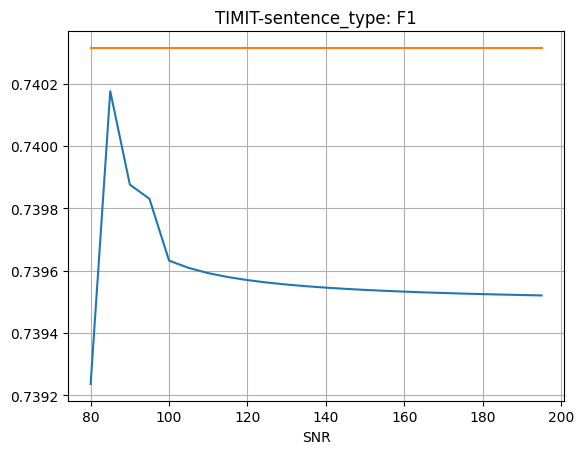

In [4]:
# Baseline: train on clean, test on noise
import yaml
import os
import matplotlib.pyplot as plt 
import numpy as np
data_dict = {}
for seed in [0]:
    for i,snr in enumerate(range(80, 200, 5)):
        path = (
            f"results/test/training/"
            f"TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_"
            f"80-195_{seed}/_test{i}/test_holistic.yaml"
        )

        with open(path, "r") as f:
            data = yaml.safe_load(f)   # ← 正确方式
            # print(snr, data['f1']['all'])
            if snr in data_dict:
                data_dict[snr].append(data['f1']['all'])
            else:
                data_dict[snr] = [data['f1']['all']]

x = list(data_dict.keys())
mean_list = np.array([np.mean(data_dict[s]) for s in x])
std_list = np.array([np.std(data_dict[s]) for s in x])
plt.plot(x, mean_list)
plt.plot(x, np.ones(len(x))*0.7403149557990653)
plt.title("TIMIT-sentence_type: F1")
plt.grid()
plt.xlabel("SNR")
plt.fill_between(x, mean_list-std_list, mean_list+std_list, alpha=0.5)

In [56]:
for d in ds_logmel['train']:
    if len(d['log_mel']) == 128:
        print(d['human_labels'])

In [55]:
len(d['log_mel'])

64

In [2]:
# split train/test for Audio_set.pt
import torch 
overlap, ds_logmel = torch.load('AudioSet.pt')

/tmp/ipykernel_1035233/3566984897.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  overlap, ds_logmel = torch.load('AudioSet.pt')
/jumbo/graphmind/yinghao/miniconda3/envs

In [22]:
overlap['Water']

defaultdict(int,
            {'Sink (filling or washing)': 48,
             'Water tap, faucet': 64,
             'Pump (liquid)': 46,
             'Toilet flush': 36,
             'Speech': 37,
             'Splash, splatter': 10,
             'Waterfall': 2,
             'Animal': 1,
             'Liquid': 6,
             'Bathtub (filling or washing)': 28,
             'Gush': 7,
             'Sizzle': 2,
             'Trickle, dribble': 6,
             'Light engine (high frequency)': 1,
             'Rain': 1,
             'Rain on surface': 1,
             'Raindrop': 1,
             'Fill (with liquid)': 13,
             'Inside, small room': 3,
             'Slosh': 4,
             'Pour': 6,
             'Hands': 1,
             'Boat, Water vehicle': 2,
             'Ocean': 1,
             'Sailboat, sailing ship': 1,
             'Stream': 6,
             'Waves, surf': 1,
             'Wind': 1,
             'Wind noise (microphone)': 1,
             'Child speech, kid spe

In [22]:
# 'Wild animals' in overlap.keys()
# 'Domestic animals, pets' in overlap.keys()
# 'Domestic animals, pets' in overlap.keys()

mapping = {
    0:'Wild animals',
    1:'Domestic animals, pets',
    2:'Bell',
    3:'Alarm',
    4:'Wind',
    5:'Water',
    6:'Wild animals+Domestic animals, pets',
    7:'Bell+Alarm',
    8:'Wind+Water'
}

In [48]:
torch.tensor(ds_logmel['train'][0]['log_mel']).size()

torch.Size([64, 1024])

In [33]:
from tqdm import tqdm 
audio_index = {}
for split in ['train', 'test']:
    audio_index[split] = {}
    for k in mapping.keys():
        audio_index[split][k] = []

for split in ['train', 'test']:
    print(split)
    for i, sample in enumerate(tqdm(ds_logmel[split])):
        if mapping[0] in sample['human_labels'] or mapping[1] in sample['human_labels']:
            audio_index[split][6].append(i)
            if mapping[0] not in sample['human_labels']:
                audio_index[split][1].append(i)
            if mapping[1] not in sample['human_labels']:
                audio_index[split][0].append(i)
        
        if mapping[2] in sample['human_labels'] or mapping[3] in sample['human_labels']:
            audio_index[split][7].append(i)
            if mapping[2] not in sample['human_labels']:
                audio_index[split][3].append(i)
            if mapping[3] not in sample['human_labels']:
                audio_index[split][2].append(i)
        
        if mapping[4] in sample['human_labels'] or mapping[5] in sample['human_labels']:
            audio_index[split][8].append(i)
            if mapping[4] not in sample['human_labels']:
                audio_index[split][5].append(i)
            if mapping[5] not in sample['human_labels']:
                audio_index[split][4].append(i)



train


100%|██████████| 18683/18683 [05:05<00:00, 61.23it/s]


test


100%|██████████| 17141/17141 [04:39<00:00, 61.29it/s]


In [35]:
# Structure of AudioSet
torch.save({
    'mapping': mapping,
    'audio_index': audio_index,
    'ds_logmel': ds_logmel,
    'overlap': overlap
}, 'AudioSet.pt')

In [41]:
for i in audio_index['train'][0]:
    if i in audio_index['test'][0]:
        print(i)

In [ ]:
for d in ds_logmel['train']:
    print(d['human_labels'])
    # break

In [ ]:
import torch
audioset = torch.load('AudioSet.pt')


In [ ]:
audioset['audio_index']['test'][2]

In [2]:
# Audio Set baseline
import yaml
train_test_type = {
     0: [0,1],
     1: [0,1],
     2: [2,3],
     3: [2,3],
     4: [4,5],
     5: [4,5],
     6: [6,7],
     7: [6,7],
    #  6: [6,7,8],
    #  7: [6,7,8],
    #  8: [6,7,8]
}

mapping = {
    0:'Wild animals',
    1:'Domestic animals, pets',
    2:'Bell',
    3:'Alarm',
    4:'Wind',
    5:'Water',
    6:'Wild animals+Domestic animals, pets',
    7:'Bell+Alarm',
    8:'Wind+Water'
}
audio_res_baseline = {}
for seed in [0]:
    for i, snr in enumerate(range(0, 20, 5)):
        for type_id in train_test_type.keys():
            # print(snr, i*9+type_id)
            if snr==0 or snr==5 or snr==10:    
                path = (
                    f"./results/test/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_None_AudioSetBaseline0-15_0/_test{i*9+type_id}/test_holistic.yaml"
                )

                with open(path, "r") as f:
                    data = yaml.safe_load(f)   # ← 正确方式
                    # print(snr, data['f1']['all'])
                    if snr in audio_res_baseline:
                        audio_res_baseline[snr].append(data['f1']['all'])
                    else:
                        audio_res_baseline[snr] = [data['f1']['all']]

            
print(audio_res_baseline)

{0: [0.42662208628841247, 0.4252116037269393, 0.43194501182054346, 0.4807925671142093, 0.34154830269134456, 0.3635948702885647, 0.4312883404658572, 0.4552892108022748], 5: [0.4920550510182869, 0.49229828074728754, 0.47965997705779523, 0.553296524592477, 0.3834773545089221, 0.37729852229470345, 0.48656174823139287, 0.49218526234085386], 10: [0.5840398645054983, 0.5710824944845728, 0.5174951217515966, 0.6205865131771018, 0.4773989000692683, 0.4783707116489679, 0.5514888816379465, 0.5803603018044631]}


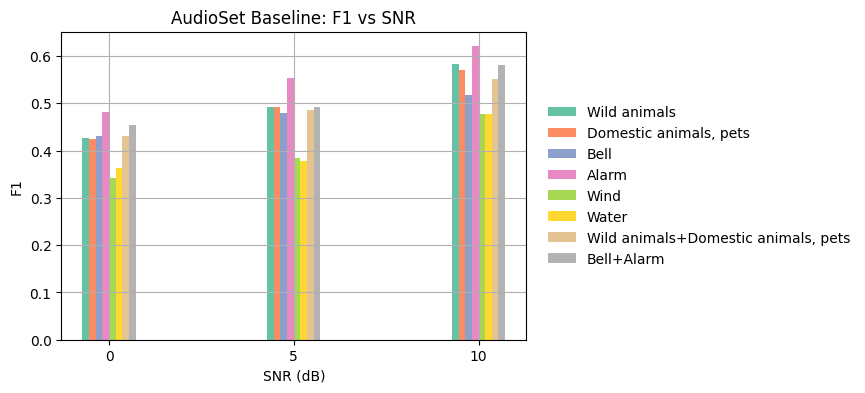

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
x = np.array(list(audio_res_baseline.keys()))           # [5, 10]
values = list(audio_res_baseline.values())               # 2 x 4
values = np.array(values)

n_groups = values.shape[1]                 # 4
bar_width = 0.18

colors = plt.cm.Set2.colors    # 或 Pastel1

plt.figure(figsize=(6,4))
for i in range(n_groups):
    plt.bar(
        x + (i - (n_groups - 1) / 2) * bar_width,
        values[:, i],
        width=bar_width,
        label=mapping[list(train_test_type.keys())[i]],
        color=colors[i]
    )

plt.xlabel('SNR (dB)')
plt.ylabel('F1')
plt.title('AudioSet Baseline: F1 vs SNR')
plt.xticks(x)
# plt.legend(loc="center left",frameon=False)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid()
plt.show()


In [4]:
train_test_type = {
     0: [0,1],
     1: [0,1],
     2: [2,3],
     3: [2,3],
     4: [4,5],
     5: [4,5],
    #  6: [6,7],
    #  7: [6,7],
     6: [6,7],
     7: [6,7],
    #  6: [6,7,8],
    #  7: [6,7,8],
    #  8: [6,7,8]
}

audioset_exp = {}

for snr_train in range(0,20,5):
    for i,noise_type_train in enumerate(train_test_type.keys()):    
        if noise_type_train not in audioset_exp:
            audioset_exp[noise_type_train] = {}
        for seed in [0]:
            for j,snr in enumerate(range(0, 15, 5)):
                for k,type_id in enumerate(train_test_type[noise_type_train]):
                    if snr_train==snr:
                        # print(noise_type_train,snr,type_id)
                        # print(j*len(train_test_type[noise_type_train])+k)
                        # print(j*len(train_test_type[noise_type_train])+k)

                        path = (
                            f"./results/test/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_AudioSet{noise_type_train}({snr})_AudioSet0-15_0/_test{j*len(train_test_type[noise_type_train])+k}/test_holistic.yaml"
                        )

                        with open(path, "r") as f:
                            data = yaml.safe_load(f)   # ← 正确方式
                            # print(data['f1']['all'])
                            # print(snr, data['f1']['all'])
                            if snr in audioset_exp[noise_type_train]:
                                audioset_exp[noise_type_train][snr].append(data['f1']['all'])
                            else:
                                audioset_exp[noise_type_train][snr] = [data['f1']['all']]
    # break

In [5]:
audioset_exp[4][5]

[0.7031617301738464, 0.6973751585240243]

In [6]:
audioset_exp[5][5]

[0.5146100049736512, 0.5471877316699006]

In [7]:
audio_res_baseline[5][4:6]

[0.3834773545089221, 0.37729852229470345]

/tmp/ipykernel_1215590/1657495174.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


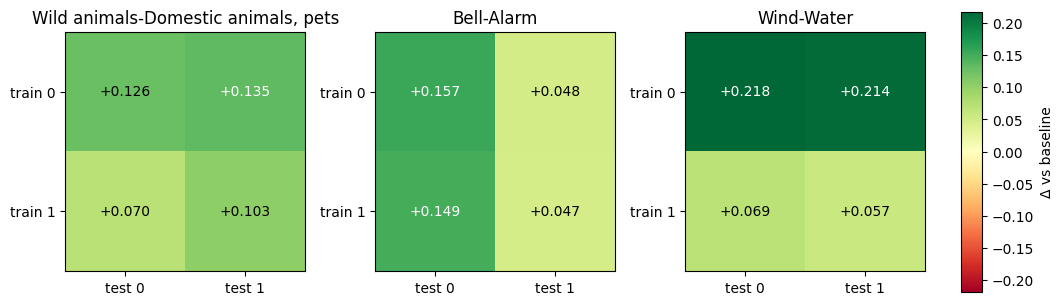

In [15]:
groups = [(0,1), (2,3), (4,5), (6,7)]

# ✅ 只保留前三个 group
groups = groups

heatmaps = []
for g in groups:
    train_0 = audioset_exp[g[0]][snr]
    train_1 = audioset_exp[g[1]][snr]
    base_0 = audio_res_baseline[snr][g[0]]
    base_1 = audio_res_baseline[snr][g[1]]

    delta_train_0 = np.array(train_0) - np.array([base_0, base_1])
    delta_train_1 = np.array(train_1) - np.array([base_0, base_1])
    heatmap = np.vstack([delta_train_0, delta_train_1])
    heatmaps.append(heatmap)

vmax = max(np.max(np.abs(hm)) for hm in heatmaps)

# ✅ subplot 改成 1×3
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4))

for ax, hm, g in zip(axes, heatmaps, groups):
    im = ax.imshow(
        hm,
        cmap="RdYlGn",
        vmin=-vmax,
        vmax=vmax
    )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([f"test 0", f"test 1"])
    ax.set_yticklabels([f"train 0", f"train 1"])
    # ax.set_xticklabels([f"test {g[0]}", f"test {g[1]}"])
    # ax.set_yticklabels([f"train {g[0]}", f"train {g[1]}"])
    ax.set_title(f"{mapping[g[0]]}-{mapping[g[1]]}")

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{hm[i, j]:+.3f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if abs(hm[i, j]) < vmax * 0.6 else "white"
            )

# ✅ colorbar 仍然单独放
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax, label="Δ vs baseline")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


In [10]:
groups

[(0, 1), (2, 3), (4, 5)]

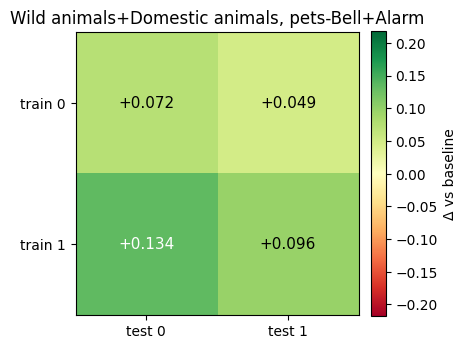

In [16]:
g = groups[3]
hm = heatmaps[3]

fig, ax = plt.subplots(figsize=(4, 4))

im = ax.imshow(
    hm,
    cmap="RdYlGn",
    vmin=-vmax,
    vmax=vmax
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f"test 0", f"test 1"])
ax.set_yticklabels([f"train 0", f"train 1"])
# ax.set_xticklabels([f"test {g[0]}", f"test {g[1]}"])
# ax.set_yticklabels([f"train {g[0]}", f"train {g[1]}"])
ax.set_title(f"{mapping[g[0]]}-{mapping[g[1]]}")

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            f"{hm[i, j]:+.3f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black" if abs(hm[i, j]) < vmax * 0.6 else "white"
        )

fig.colorbar(im, ax=ax,  fraction=0.046, pad=0.04, label="Δ vs baseline")
plt.show()


In [ ]:
audio_res_baseline[5][0]

0.4920550510182869